# 04_RQ4_Feature_Importance
Objective and methodology.

# ============================================
# RQ4: Feature Importance
# ============================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

# ============================================
# 2. Create Output Folder
# ============================================

In [2]:
os.makedirs('outputs', exist_ok=True)


# ============================================
# 3. Load Dataset
# ============================================

In [3]:
df = pd.read_csv('marketing_and_product_performance.csv')


# ============================================
# 4. Feature Engineering
# ============================================


In [4]:
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
df['Conversion_Rate'] = df['Conversion_Rate'].replace([np.inf, -np.inf], 0)

def categorize(rate):
    if rate < 0.02:
        return 0
    elif rate < 0.05:
        return 1
    else:
        return 2

df['Target'] = df['Conversion_Rate'].apply(categorize)

# Prepare Data
X = df.drop(columns=['Target', 'Conversion_Rate'])
y = df['Target']

# Encode
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================================
# 5. Train Best Model (XGBoost)
# ============================================


In [11]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='mlogloss',
    n_jobs=-1
)

model.fit(X_train, y_train)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# ============================================
# 6.Feature Importance
# ============================================



In [13]:
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Top 10
top_features = feat_df.head(10)

print("\nTop Features:\n")
print(top_features)

# Save table
top_features.to_csv("RQ4_outputs/RQ4_Feature_Importance.csv", index=False)


Top Features:

                          Feature  Importance
2                     Conversions    0.683125
1                          Clicks    0.202494
50007     Common_Keywords_Durable    0.019278
0                          Budget    0.012370
30007   Subscription_Tier_Premium    0.010886
8                    Bundle_Price    0.010263
4                             ROI    0.009985
30008  Subscription_Tier_Standard    0.008561
3               Revenue_Generated    0.008497
5             Subscription_Length    0.008468



# ============================================
# 7. Plot
# ============================================

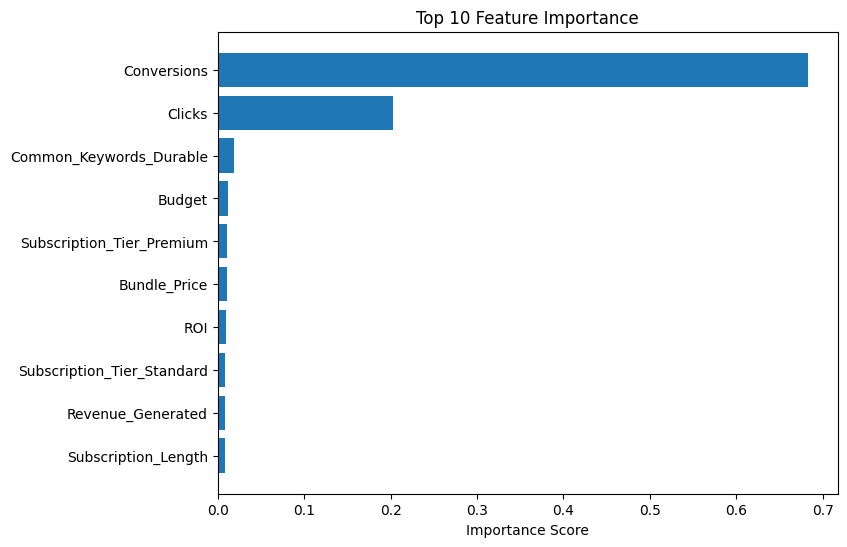

In [14]:
plt.figure(figsize=(8,6))

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")

plt.savefig("RQ4_outputs/RQ4_Feature_Importance.pdf")
plt.show()